<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/08-card-credit-risk/card_credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# [Cell 1] Kaggle 데이터 다운로드 + 기본 탐색
# ============================================================
!pip install --quiet kaggle

import os
import pandas as pd
import numpy as np
from getpass import getpass

# ------------------------------------------------------------
# Kaggle 인증 (07번 모듈과 동일한 방식)
# ------------------------------------------------------------
os.environ['KAGGLE_USERNAME'] = input("Kaggle 사용자명(username)을 입력하세요: ")
os.environ['KAGGLE_KEY'] = getpass("Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ")

# ------------------------------------------------------------
# "Default of Credit Card Clients" 데이터셋 다운로드
# ------------------------------------------------------------
!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
!unzip -o default-of-credit-card-clients-dataset.zip

df = pd.read_csv('UCI_Credit_Card.csv')
print(f"데이터 크기: {df.shape}")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n다음달 채무불이행(default) 비율: {df['default.payment.next.month'].mean()*100:.2f}%")
print(df.head())

Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 139MB/s]

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     
데이터 크기: (30000, 25)

컬럼 목록:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

다음달 채무불이행(default) 비율: 22.12%
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1

LIMIT_BAL: 신용한도
SEX, EDUCATION, MARRIAGE, AGE: 인구통계
PAY_0 ~ PAY_6: 최근 6개월간 월별 결제상태 (–1=정상결제, 1=1개월 연체, 2=2개월 연체... 값이 클수록 연체 심각)
BILL_AMT1 ~ BILL_AMT6: 월별 청구금액
PAY_AMT1 ~ PAY_AMT6: 월별 실제 결제금액
default.payment.next.month: 다음달 채무불이행 여부(1=불이행) — 예측할 타깃

=== 파생변수 요약 통계 ===
       recent_delay  max_delay_6m  delay_freq_6m  avg_payment_ratio  \
count  30000.000000  30000.000000   30000.000000       30000.000000   
mean       0.356767      0.682200       0.834200           0.415109   
std        0.760594      1.073518       1.554303           0.802728   
min        0.000000      0.000000       0.000000           0.000000   
25%        0.000000      0.000000       0.000000           0.019956   
50%        0.000000      0.000000       0.000000           0.047464   
75%        0.000000      2.000000       1.000000           0.235349   
max        8.000000      8.000000       6.000000           3.000000   

       avg_utilization  
count     30000.000000  
mean          0.372851  
std           0.349678  
min           0.000000  
25%           0.029997  
50%           0.284834  
75%           0.687929  
max           2.000000  


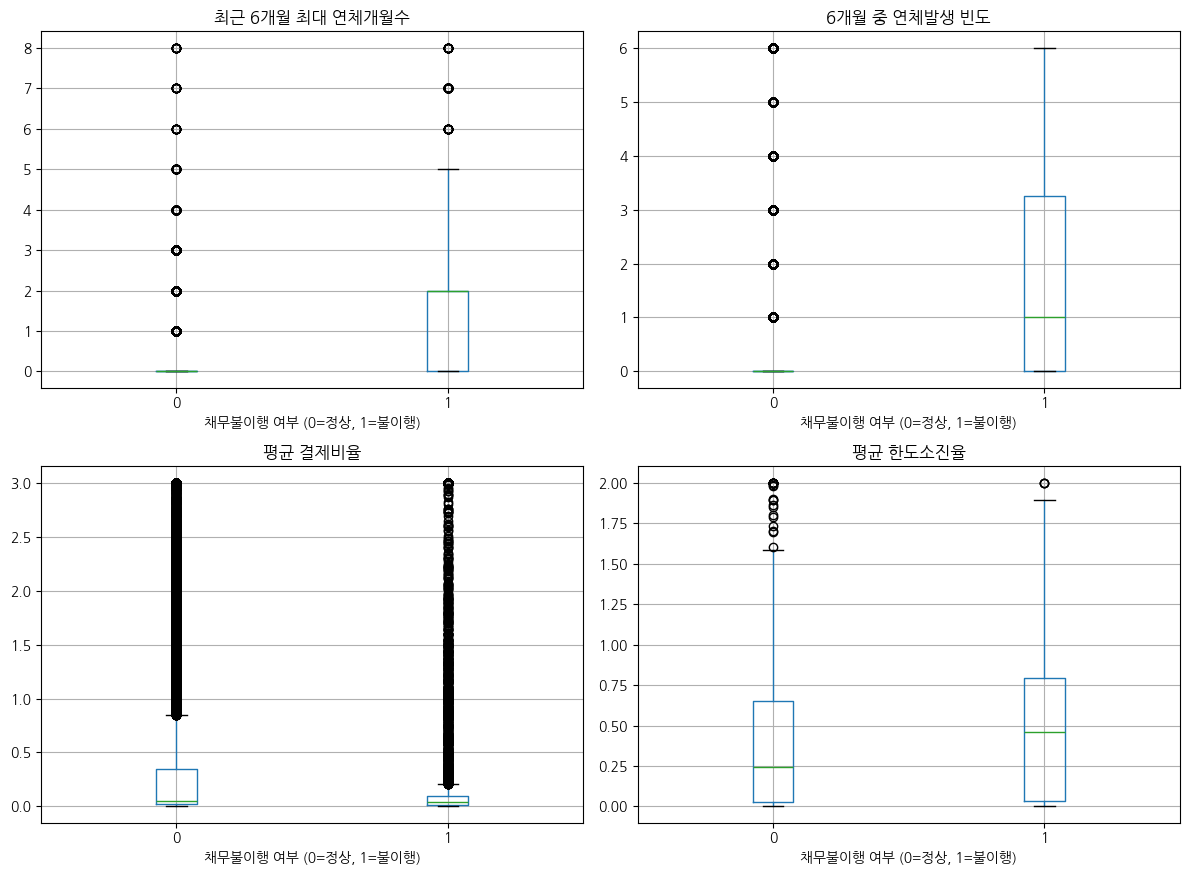

In [2]:
# ============================================================
# [Cell 2] 탐색적 분석 + 피처 엔지니어링 (행동패턴 지표 생성)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# 1) 타깃 컬럼명 정리 (마침표가 있어 다루기 불편하므로 변경)
# ------------------------------------------------------------
df = df.rename(columns={'default.payment.next.month': 'default'})

# ------------------------------------------------------------
# 2) 연체 관련 파생변수 생성
# ------------------------------------------------------------
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
paid_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 최근 연체 심각도 (PAY_0이 최신 달 상태, 음수는 정상결제라 0으로 클리핑)
df['recent_delay'] = df['PAY_0'].clip(lower=0)

# 최근 6개월 중 최대 연체 개월수
df['max_delay_6m'] = df[pay_cols].clip(lower=0).max(axis=1)

# 연체 발생 빈도 (6개월 중 연체가 있었던 달의 개수)
df['delay_freq_6m'] = (df[pay_cols] > 0).sum(axis=1)

# 평균 결제비율 (청구액 대비 실제 결제액, 0으로 나누기 방지 위해 청구액 0인 경우 1로 처리해 비율 왜곡 방지)
bill_safe = df[bill_cols].replace(0, np.nan)
df['avg_payment_ratio'] = (df[paid_cols].values / bill_safe.values).mean(axis=1)
df['avg_payment_ratio'] = df['avg_payment_ratio'].fillna(0).clip(0, 3)  # 극단치 완화

# 평균 한도소진율 (청구액 대비 신용한도)
df['avg_utilization'] = (df[bill_cols].mean(axis=1) / df['LIMIT_BAL']).clip(0, 2)

print("=== 파생변수 요약 통계 ===")
print(df[['recent_delay', 'max_delay_6m', 'delay_freq_6m', 'avg_payment_ratio', 'avg_utilization']].describe())

# ------------------------------------------------------------
# 3) 채무불이행 여부에 따른 파생변수 분포 비교 (직관 검증)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, col, title in zip(axes.flat,
    ['max_delay_6m', 'delay_freq_6m', 'avg_payment_ratio', 'avg_utilization'],
    ['최근 6개월 최대 연체개월수', '6개월 중 연체발생 빈도', '평균 결제비율', '평균 한도소진율']):
    df.boxplot(column=col, by='default', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('채무불이행 여부 (0=정상, 1=불이행)')

plt.suptitle('')
plt.tight_layout()
plt.show()

연체 관련 지표 2개(왼쪽 위, 오른쪽 위): 채무불이행(1) 그룹이 정상(0) 그룹보다 최대연체개월수·연체빈도 모두 뚜렷하게 높게 나옴. — 경제적 직관과 정확히 일치하는 결과.

한도소진율(오른쪽 아래): 채무불이행 그룹의 중앙값(약 0.47)이 정상 그룹(약 0.24)보다 확실히 높음. 한도에 가까울수록 재무적으로 빠듯하다는 가설이 맞음.

평균 결제비율(왼쪽 아래)만 판단이 애매. — 극단치(최대 3.0)가 너무 많아서 박스 자체가 0 근처에 눌려 보이고, 두 그룹의 차이가 시각적으로 보이지 않음. 요약통계표를 보면 전체 중앙값이 0.047로 매우 낮고 75%도 0.235에 불과한 걸 보면, 데이터 자체가 심하게 우측으로 치우친(대부분 소액만 결제) 분포라 박스플롯이 이상치에 압도된 것.

In [3]:
# ============================================================
# [Cell 2b] 평균 결제비율의 그룹별 차이를 숫자로 명확히 확인
# ============================================================
print("=== 채무불이행 여부별 평균 결제비율 통계 ===")
print(df.groupby('default')['avg_payment_ratio'].describe())

=== 채무불이행 여부별 평균 결제비율 통계 ===
           count      mean       std  min       25%       50%       75%  max
default                                                                     
0        23364.0  0.456413  0.838302  0.0  0.020935  0.049010  0.351703  3.0
1         6636.0  0.269686  0.641681  0.0  0.017933  0.043323  0.094015  3.0


채무불이행(1) 그룹의 평균 결제비율(0.27)이 정상(0) 그룹(0.46)보다 낮음. 박스플롯에서는 극단치 때문에 가려졌지만, 숫자로 보니 리볼빙(최소금액만 결제) 성향 가설이 명확히 확인됨.

학습셋: 21000개 (불이행 4645개) / 검증셋: 9000개 (불이행 1991개)

=== 모델 성능 비교 ===
로지스틱 회귀 - ROC-AUC: 0.745, KS: 0.393
XGBoost      - ROC-AUC: 0.766, KS: 0.412

XGBoost 피처 중요도:
             feature  importance
3       max_delay_6m    0.618061
2       recent_delay    0.213980
4      delay_freq_6m    0.074945
6    avg_utilization    0.032111
0          LIMIT_BAL    0.026038
5  avg_payment_ratio    0.019474
1                AGE    0.015391


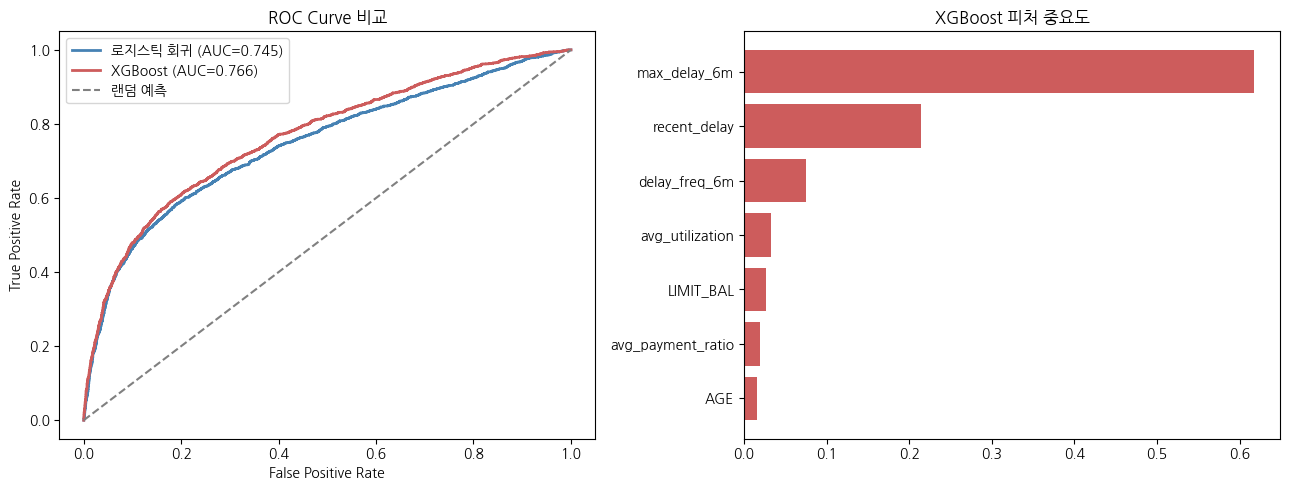

In [4]:
# ============================================================
# [Cell 3] 로지스틱 회귀 vs XGBoost 모델링 및 비교
# ============================================================
!pip install --quiet xgboost

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1) 피처 구성: 원본 변수 + 파생변수(행동패턴 지표)
# ------------------------------------------------------------
features = ['LIMIT_BAL', 'AGE', 'recent_delay', 'max_delay_6m',
            'delay_freq_6m', 'avg_payment_ratio', 'avg_utilization']
X = df[features]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"학습셋: {len(X_train)}개 (불이행 {y_train.sum()}개) / 검증셋: {len(X_test)}개 (불이행 {y_test.sum()}개)")

# ------------------------------------------------------------
# 2) 로지스틱 회귀 (표준화 + 클래스 가중치 보정)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit_model = LogisticRegression(class_weight='balanced', random_state=42)
logit_model.fit(X_train_scaled, y_train)
logit_proba = logit_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 3) XGBoost
# ------------------------------------------------------------
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 4) 성능 비교
# ------------------------------------------------------------
def calc_ks(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(tpr - fpr)

auc_logit, auc_xgb = roc_auc_score(y_test, logit_proba), roc_auc_score(y_test, xgb_proba)
ks_logit, ks_xgb = calc_ks(y_test, logit_proba), calc_ks(y_test, xgb_proba)

print(f"\n=== 모델 성능 비교 ===")
print(f"로지스틱 회귀 - ROC-AUC: {auc_logit:.3f}, KS: {ks_logit:.3f}")
print(f"XGBoost      - ROC-AUC: {auc_xgb:.3f}, KS: {ks_xgb:.3f}")

# ------------------------------------------------------------
# 5) XGBoost 피처 중요도
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    'feature': features, 'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nXGBoost 피처 중요도:")
print(importance_df)

# ------------------------------------------------------------
# 6) 시각화: ROC 곡선 비교 + 피처 중요도
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, color in [('로지스틱 회귀', logit_proba, 'steelblue'), ('XGBoost', xgb_proba, 'indianred')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color, lw=2)
axes[0].plot([0,1],[0,1], linestyle='--', color='gray', label='랜덤 예측')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve 비교'); axes[0].legend()

axes[1].barh(importance_df['feature'], importance_df['importance'], color='indianred')
axes[1].set_title('XGBoost 피처 중요도')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

표본이 3만 건으로 충분히 크니 이번엔 XGBoost(0.766)가 로지스틱 회귀(0.745)를 확실히 앞섰고, 05번 SME 모듈에서 봤던 "소표본에선 단순모델이 유리하다"는 결론과 정반대 결과가 나온 게 좋은 대비점이 됨. 피처 중요도도 max_delay_6m과 recent_delay가 전체의 83%를 차지해서, "연체 이력이 채무불이행의 가장 강력한 신호"라는 카드업계 통설을 데이터로 재확인하였음.